# 10단계 · 멀티종목 포트폴리오 백테스팅

## 09번 전략을 여러 종목에 동시 적용

09번(단일 종목 + 부분 매수/매도)을 **5개 섹터 대표주**로 확장한다.  
각 종목의 ADX 국면이 달라 동시에 모두 하락장에 빠질 확률이 낮아진다 → **분산투자 효과**

```
09번:  삼성전자 1종목  →  size_series (1D)  →  단일 백테스트
10번:  5종목 포트폴리오 →  size_df (5컬럼)  →  공유 현금 포트폴리오
```

## 포트폴리오 구성 종목 (WICS 섹터 대표주)

| 종목 | 코드 | WICS 섹터 |
|------|------|----------|
| 삼성전자 | 005930.KS | IT (반도체) |
| SK하이닉스 | 000660.KS | IT (메모리) |
| NAVER | 035420.KS | 경기관련소비재 (인터넷) |
| 현대차 | 005380.KS | 경기관련소비재 (자동차) |
| POSCO홀딩스 | 005490.KS | 소재 (철강) |

## 핵심 설계 원칙

```
[진입 비중 계산 방식]
  최종 비중 = 신호 크기 × (종목 모멘텀 / 유효 종목 모멘텀 합)

[국면별 모멘텀 윈도우 자동 선택]
  UPTREND    → 126일(6개월): 추세가 길게 이어지므로 장기 모멘텀 신뢰도 높음
  TRANSITION →  63일(3개월): 방향 불확실, 중기 모멘텀으로 중간값 사용
  SIDEWAYS   →  21일(1개월): 단기 등락 반복, 빠른 반응 필요
  DOWNTREND  → 진입 안 함   (전량 청산 국면)

[가변 투자 비중]
  신호 많고 모멘텀 강한 날 → 투자 비중 증가 (현금 비중 감소)
  신호 없거나 모멘텀 약한 날 → 현금 대기
  음수 모멘텀 종목 → 신호 발생해도 진입 제외

공유 현금(cash_sharing=True): 5종목이 하나의 현금 풀을 나눠 씀
```

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))

# 모듈 변경 시 캐시 없이 재로드
import importlib
import vbt_backtest.portfolio_backtest
importlib.reload(vbt_backtest.portfolio_backtest)

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from vbt_backtest.config import (
    FEES, SLIPPAGE,
    ADX_PARAM_GRID, WF_TRAIN_MONTHS, WF_TEST_MONTHS,
    ADX_THRESHOLD_DEFAULT, ADX_SIDEWAYS_DEFAULT,
)

from vbt_backtest.portfolio_backtest import (
    load_portfolio_data,
    build_size_df,
    run_portfolio_backtest,
    run_bh_portfolio,
    run_bh_single,
    build_metrics_table,
    plot_equity_curves,
    plot_weight_heatmap,
    plot_contribution,
    plot_diversification,
    plot_yearly_returns,
)

# ── 설정 ────────────────────────────────────────────────────────────────────
START    = '2019-01-01'
END      = '2024-12-31'

ADX_THRESHOLD = ADX_THRESHOLD_DEFAULT
ADX_SIDEWAYS  = ADX_SIDEWAYS_DEFAULT

# ── 모멘텀 필터 설정 ─────────────────────────────────────────────────────────
# 모멘텀 윈도우는 국면에 따라 자동 선택된다 (고정값 불필요)
#   UPTREND    → 126일(6개월)
#   TRANSITION →  63일(3개월)
#   SIDEWAYS   →  21일(1개월)
MIN_MOMENTUM = 0.0  # 음수 모멘텀 종목은 진입하지 않음

TICKERS = {
    '삼성전자':    '005930.KS',
    'SK하이닉스':  '000660.KS',
    'NAVER':      '035420.KS',
    '현대차':      '005380.KS',
    'POSCO홀딩스': '005490.KS',
}
NAMES = list(TICKERS.keys())
N     = len(TICKERS)

print(f'포트폴리오 종목 수: {N}개')
print(f'모멘텀 윈도우: 국면별 자동 선택 (UPTREND=126일 / TRANSITION=63일 / SIDEWAYS=21일)')
print(f'모멘텀 최소 기준: {MIN_MOMENTUM:.0%} (음수 모멘텀 종목 제외)')
print(f'ADX threshold={ADX_THRESHOLD}')

포트폴리오 종목 수: 5개
모멘텀 윈도우: 국면별 자동 선택 (UPTREND=126일 / TRANSITION=63일 / SIDEWAYS=21일)
모멘텀 최소 기준: 0% (음수 모멘텀 종목 제외)
ADX threshold=25.0


---
## 1단계 · 5종목 데이터 로드

In [2]:
data = load_portfolio_data(TICKERS, start=START, end=END)

close_df  = data['close']
high_df   = data['high']
low_df    = data['low']
volume_df = data['volume']

print(f'기간  : {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'거래일: {len(close_df)}일')
print()

print('=== 종목별 시작가 → 종가 (수익률) ===')
for name in NAMES:
    s = close_df[name].iloc[0]
    e = close_df[name].iloc[-1]
    print(f'  {name:10s}: {s:>8,.0f}원 → {e:>8,.0f}원  ({(e/s-1):.1%})')

기간  : 2019-01-02 ~ 2024-12-30
거래일: 1475일

=== 종목별 시작가 → 종가 (수익률) ===
  삼성전자      :   32,297원 →   51,969원  (60.9%)
  SK하이닉스    :   56,288원 →  171,782원  (205.2%)
  NAVER     :  114,435원 →  195,872원  (71.2%)
  현대차       :   88,118원 →  197,933원  (124.6%)
  POSCO홀딩스  :  182,284원 →  243,078원  (33.4%)


---
## 2단계 · 종목별 신호 생성 → 국면별 모멘텀 비례 가중치 → size_df 구성

각 종목에 partial_auto_strategy를 독립적으로 적용한 뒤,  
**시장 국면에 따라 다른 모멘텀 윈도우**로 비중을 배분한다.

```
[국면별 모멘텀 윈도우]
UPTREND    → 126일(6개월): 추세가 길게 이어지므로 장기 모멘텀이 신뢰도 높음
TRANSITION →  63일(3개월): 방향 불확실, 중기 모멘텀으로 중간값 사용
SIDEWAYS   →  21일(1개월): 단기 등락 반복, 빠른 반응 필요
DOWNTREND  → 진입 안 함   (어차피 전량 청산 국면)

[비중 계산 흐름]
1. 종목별 진입 신호 생성 (골든크로스 40% / MA20지지 70% / BB하단 30%)
2. 당일 국면에 맞는 모멘텀 윈도우로 수익률 계산
3. 음수 모멘텀 종목 진입 제외
4. 통과 종목의 모멘텀 합 대비 비율로 가중치 산출
5. 최종 비중 = 신호 크기 × 모멘텀 가중치 (가변 투자 비중)

[비중 계산 예시] 어느 날 3종목에 신호 발생 (UPTREND 국면 → 126일 모멘텀):
  삼성전자   모멘텀 20%, 신호 0.4 → 가중치 20/35 = 0.571 → 비중 0.4 × 0.571 = 22.8%
  SK하이닉스 모멘텀 10%, 신호 0.7 → 가중치 10/35 = 0.286 → 비중 0.7 × 0.286 = 20.0%
  현대차     모멘텀  5%, 신호 0.4 → 가중치  5/35 = 0.143 → 비중 0.4 × 0.143 =  5.7%
  ──────────────────────────────────────────────────────────────────────────
  당일 총 투자 비중 = 48.5%  /  나머지 51.5% = 현금
```

In [3]:
size_df, signal_counts = build_size_df(
    close_df, high_df, low_df, volume_df,
    adx_threshold=ADX_THRESHOLD,
    adx_sideways=ADX_SIDEWAYS,
    min_momentum=MIN_MOMENTUM,
)

import pandas as pd
df_signals = pd.DataFrame(signal_counts).T
print('=== 종목별 신호 횟수 ===')
print(df_signals.to_string())
print()

# 모멘텀 필터 후 실제 진입일 수 확인
entry_days = (size_df > 0).sum()
print('=== 모멘텀 필터 후 실제 진입일 수 ===')
for name in NAMES:
    print(f'  {name:10s}: {entry_days[name]}일')
print()

non_nan = size_df.stack()
print(f'size_df 비중 범위: {non_nan.min():.3f} ~ {non_nan.max():.3f}')
print(f'(국면별 모멘텀 가중치 적용 → 비중이 날짜/국면별로 가변)')

=== 종목별 신호 횟수 ===
          진입 횟수  1차 익절  2차 청산
삼성전자         13     12     15
SK하이닉스       14     12      9
NAVER        11     11     13
현대차          17      9     16
POSCO홀딩스     22     14     18

=== 모멘텀 필터 후 실제 진입일 수 ===
  삼성전자      : 18일
  SK하이닉스    : 13일
  NAVER     : 14일
  현대차       : 11일
  POSCO홀딩스  : 21일

size_df 비중 범위: 0.000 ~ 0.700
(국면별 모멘텀 가중치 적용 → 비중이 날짜/국면별로 가변)


---
## 3단계 · 포트폴리오 백테스팅 실행

**`group_by=True` + `cash_sharing=True`**:  
5종목이 하나의 현금 풀을 공유 → 진정한 포트폴리오 시뮬레이션

In [4]:
pf_09    = run_portfolio_backtest(close_df, size_df, fees=FEES, slippage=SLIPPAGE)
pf_bh    = run_bh_portfolio(close_df, fees=FEES, slippage=SLIPPAGE)
pf_bh_ss = run_bh_single(close_df['삼성전자'], fees=FEES, slippage=SLIPPAGE)

val_09 = pf_09.value()
val_bh = pf_bh.value()

print(f'09번 포트폴리오 총수익률: {(val_09.iloc[-1]/val_09.iloc[0]-1):.2%}')
print(f'BH 균등포트폴리오 총수익률: {(val_bh.iloc[-1]/val_bh.iloc[0]-1):.2%}')
print(f'삼성전자 단독 BH 총수익률: {pf_bh_ss.total_return():.2%}')

09번 포트폴리오 총수익률: 20.58%
BH 균등포트폴리오 총수익률: 99.21%
삼성전자 단독 BH 총수익률: 60.11%


---
## 4단계 · 자산 곡선 비교

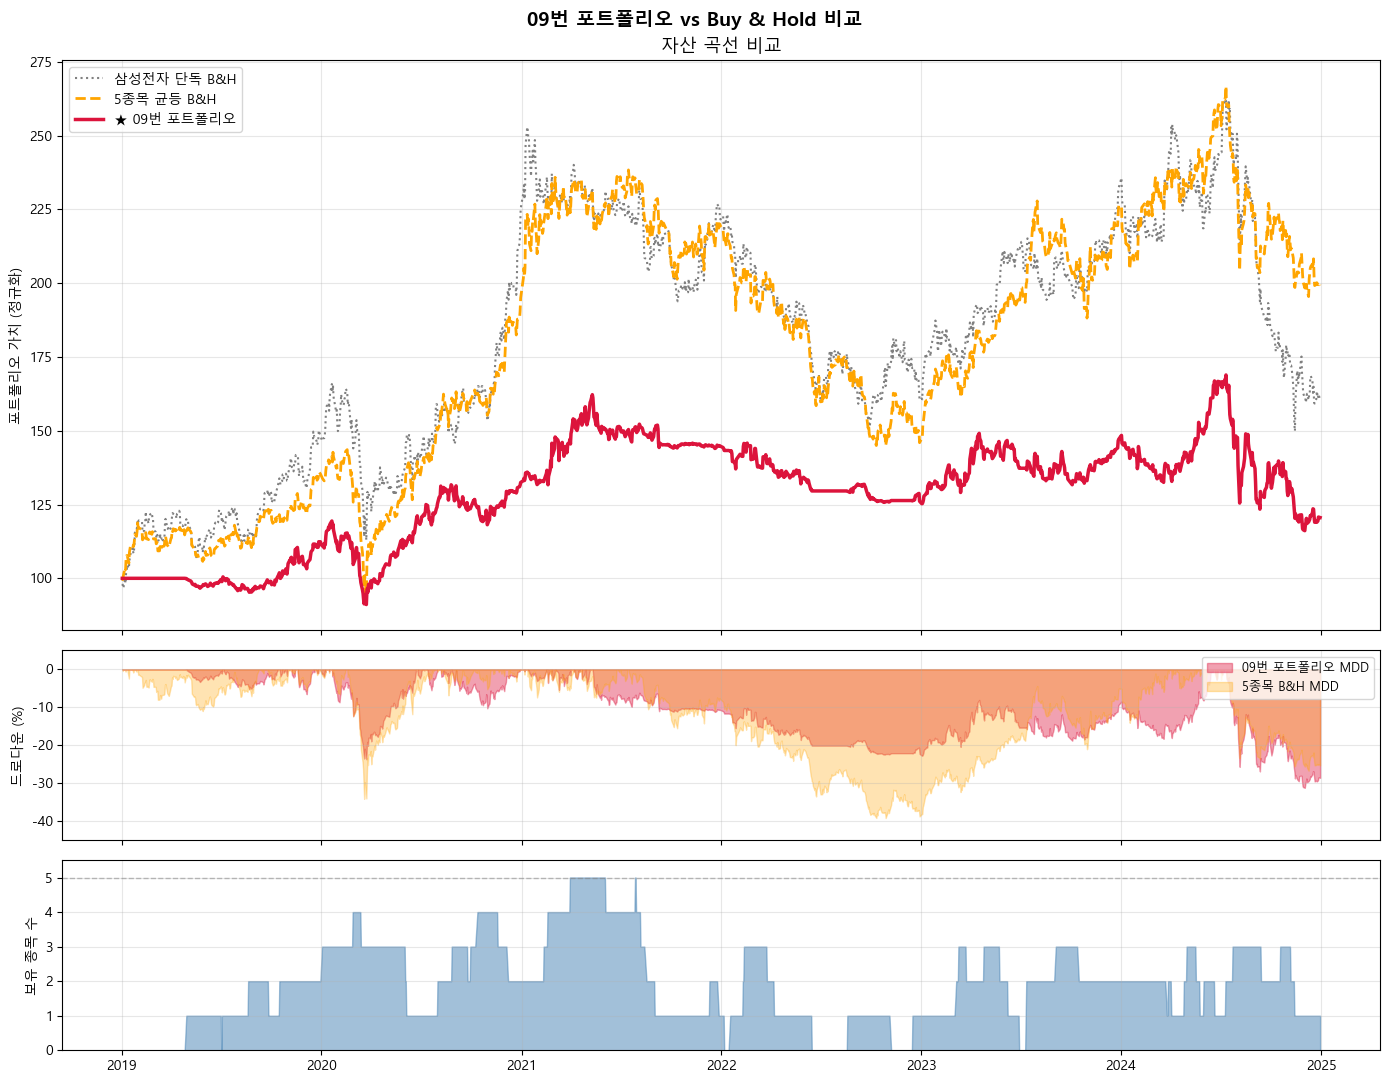

In [5]:
plot_equity_curves(pf_09, pf_bh, pf_bh_ss, names=NAMES, n=N)

---
## 5단계 · 성과 비교 테이블

In [6]:
df_perf = build_metrics_table(pf_09, pf_bh, pf_bh_ss, close_df, bh_ss_name='삼성전자')
print(f'=== 성과 비교 ({close_df.index[0].date()} ~ {close_df.index[-1].date()}) ===')
print(df_perf.to_string())

=== 성과 비교 (2019-01-02 ~ 2024-12-30) ===
                     총 수익률    CAGR  연간 변동성  샤프비율      MDD Calmar
전략                                                              
삼성전자 단독 B&H         60.51%   8.22%  26.27%  0.44  -42.85%   0.19
5종목 균등 B&H          99.21%  12.19%  24.03%  0.61  -39.20%   0.31
★ 09번 포트폴리오         20.58%   3.17%  18.27%  0.27  -31.24%   0.10
  삼성전자 단독 B&H       60.91%   8.26%  26.27%  0.44  -42.85%   0.19
  SK하이닉스 단독 B&H    205.19%  20.46%  38.86%  0.68  -48.20%   0.42
  NAVER 단독 B&H      71.16%   9.38%  35.04%  0.44  -65.45%   0.14
  현대차 단독 B&H       124.62%  14.46%  34.47%  0.57  -52.59%   0.27
  POSCO홀딩스 단독 B&H   33.35%   4.92%  37.24%  0.32  -60.31%   0.08


---
## 6단계 · 포지션 히트맵 (날짜 × 종목)

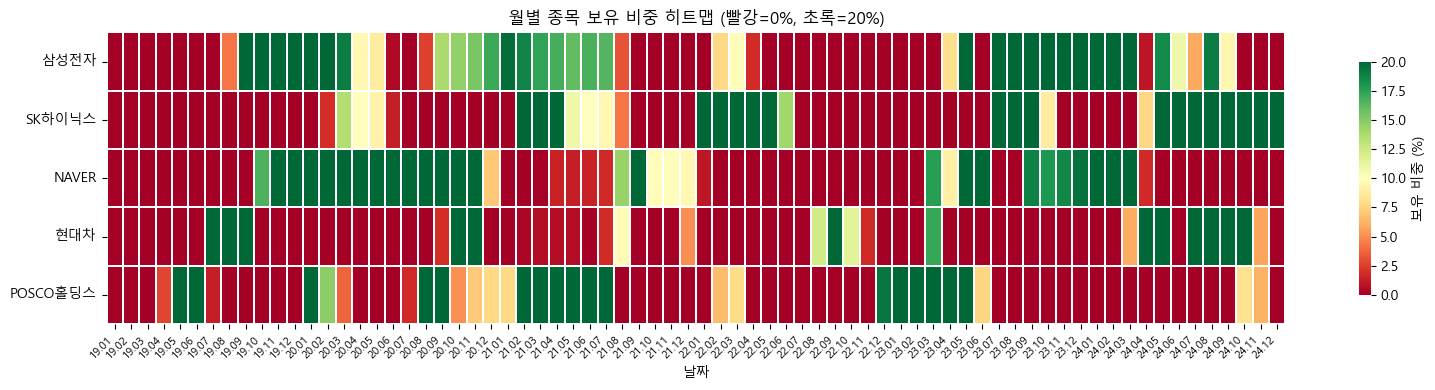


=== 종목별 평균 포지션 비중 ===
  삼성전자      : 13.6%  (최대 71.4%)
  SK하이닉스    : 11.0%  (최대 45.3%)
  NAVER     : 11.9%  (최대 60.9%)
  현대차       : 7.0%  (최대 47.1%)
  POSCO홀딩스  : 9.8%  (최대 48.9%)


In [7]:
plot_weight_heatmap(pf_09, names=NAMES)

---
## 7단계 · 종목별 수익 기여도 분석

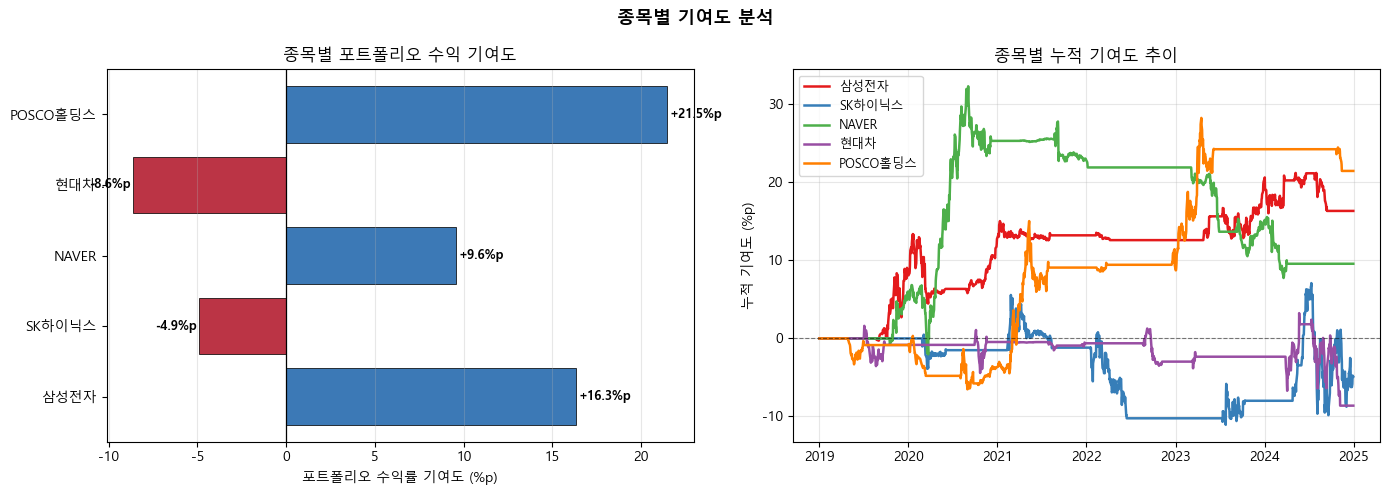


=== 종목별 기여도 순위 ===
  POSCO홀딩스  : +21.46%p
  삼성전자      : +16.34%p
  NAVER     : +9.57%p
  SK하이닉스    : -4.90%p
  현대차       : -8.61%p


In [8]:
plot_contribution(pf_09, close_df, names=NAMES)

---
## 8단계 · 분산투자 효과 분석

**분산투자 효과**: 종목 간 상관관계가 낮을수록 포트폴리오 변동성이 개별 종목보다 낮아진다.

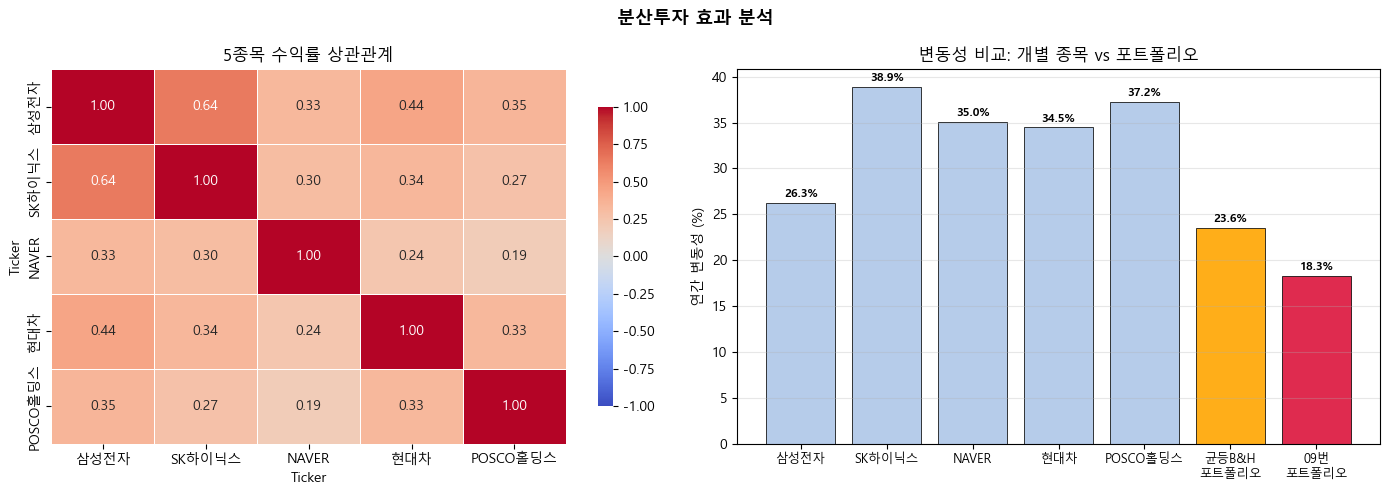


=== 분산투자 효과 ===
개별 종목 평균 변동성: 34.4%
균등 B&H 포트폴리오:  23.6%  (개별 대비 69%)
09번 포트폴리오:       18.3%  (개별 대비 53%)


In [9]:
plot_diversification(pf_09, pf_bh, close_df, names=NAMES)

---
## 9단계 · 연도별 성과 (캘린더 뷰)

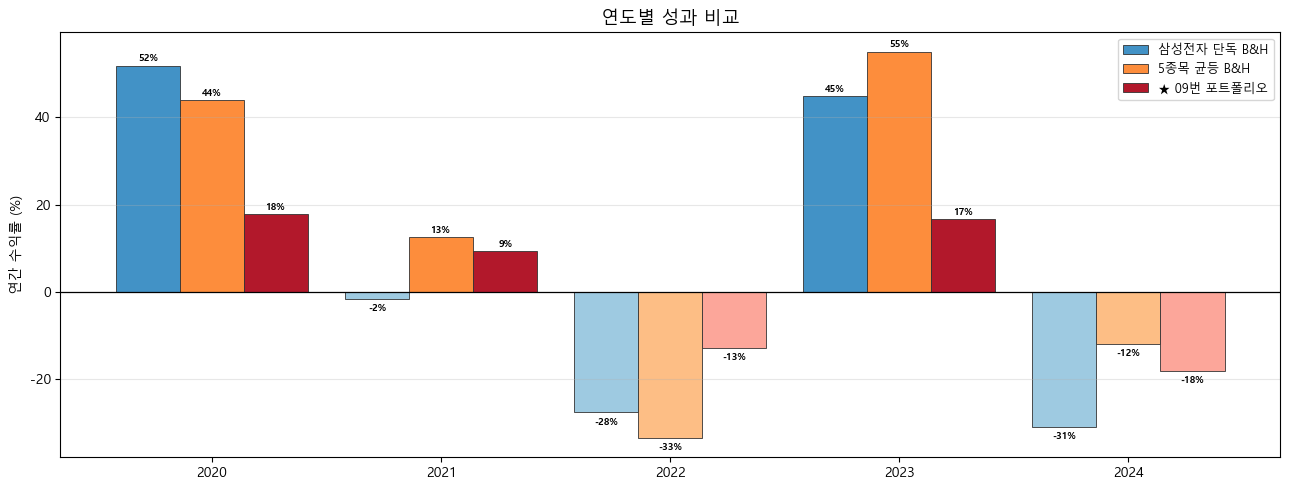

In [10]:
plot_yearly_returns(pf_09, pf_bh, pf_bh_ss, bh_ss_name='삼성전자', n=N)

---
## 정리

### 단일 종목 vs 멀티 포트폴리오

| 구분 | 09번 (삼성 단독) | 10번 (5종목 포트폴리오) |
|------|----------------|---------------------|
| 진입 기회 | 삼성전자 ADX만 의존 | 5종목 중 하나라도 신호 → 진입 |
| 하락 위험 | 삼성 하락 = 전체 손실 | 5종목 동시 하락 가능성 낮음 |
| 변동성 | 개별 종목 변동성 | 분산 효과로 낮아짐 |
| 복잡도 | 단순 | size_df 관리 필요 |

### 분산투자 핵심 공식

```
포트폴리오 변동성 < 개별 종목 평균 변동성
  → 상관관계가 1보다 낮을 때 항상 성립
  → 상관관계가 낮을수록 효과 큼
```

### 다음 개선 방향

```
1. 종목별 Walk-Forward 최적화: 각 종목에 최적 (threshold, scale) 독립 탐색
2. 동적 비중 조절: 변동성 역비례 비중 (낮은 변동성 종목 → 더 많은 비중)
3. 섹터 확장: 5개 → WICS 전체 섹터 대표주 (금융/에너지/헬스케어 추가)
4. 리밸런싱: 월별/분기별 비중 재조정
5. 롱숏: STRONG_BEAR 국면 종목 공매도 (인버스 ETF 활용)
```